In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("Loebner Prize Winners.csv")

# Preview
df.head()

,ID,Year,Winner,Program,Company,Nationality,Description,Winner Link,Program Link,Winning Dialogue Transcript,Sources
0,"Albert One by Robby Garner, 1998",1998,Robby Garner,Albert One,NaN,United States,Albert One is an AI chatterbot bot created by ...,http://en.wikipedia.org/wiki/Robby_Garner,http://en.wikipedia.org/wiki/Albert_One,NaN,http://loebner.net/Prizef/loebner-prize.html
1,"Albert One by Robby Garner, 1999",1999,Robby Garner,Albert One,NaN,United States,Albert One is an AI chatterbot bot created by ...,http://en.wikipedia.org/wiki/Robby_Garner,http://en.wikipedia.org/wiki/Albert_One,NaN,http://loebner.net/Prizef/loebner-prize.html
2,Artificial Linguistic Internet Computer Entity...,2000,Richard Wallace,Artificial Linguistic Internet Computer Entity...,NaN,United States,A.L.I.C.E. (Artificial Linguistic Internet Com...,http://en.wikipedia.org/wiki/Richard_Wallace_(...,http://en.wikipedia.org/wiki/Artificial_Lingui...,NaN,http://loebner.net/Prizef/loebner-prize.html
3,Artificial Linguistic Internet Computer Entity...,2001,Richard Wallace,Artificial Linguistic Internet Computer Entity...,NaN,United States,A.L.I.C.E. (Artificial Linguistic Internet Com...,http://en.wikipedia.org/wiki/Richard_Wallace_(...,http://en.wikipedia.org/wiki/Artificial_Lingui...,http://loebner.net/Prizef/2001_Contest/Richard...,http://loebner.net/Prizef/loebner-prize.html
4,Artificial Linguistic Internet Computer Entity...,2004,Richard Wallace,Artificial Linguistic Internet Computer Entity...,NaN,United States,A.L.I.C.E. (Artificial Linguistic Internet Com...,http://en.wikipedia.org/wiki/Richard_Wallace_(...,http://en.wikipedia.org/wiki/Artificial_Lingui...,http://loebner.net/Prizef/2004_Contest/Wallace...,http://loebner.net/Prizef/loebner-prize.html


In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
df['processed_text'] = df['Description'].apply(preprocess)

df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,ID,Year,Winner,Program,Company,Nationality,Description,Winner Link,Program Link,Winning Dialogue Transcript,Sources,processed_text
0,"Albert One by Robby Garner, 1998",1998,Robby Garner,Albert One,NaN,United States,Albert One is an AI chatterbot bot created by ...,http://en.wikipedia.org/wiki/Robby_Garner,http://en.wikipedia.org/wiki/Albert_One,NaN,http://loebner.net/Prizef/loebner-prize.html,albert one ai chatterbot bot created robby gar...
1,"Albert One by Robby Garner, 1999",1999,Robby Garner,Albert One,NaN,United States,Albert One is an AI chatterbot bot created by ...,http://en.wikipedia.org/wiki/Robby_Garner,http://en.wikipedia.org/wiki/Albert_One,NaN,http://loebner.net/Prizef/loebner-prize.html,albert one ai chatterbot bot created robby gar...
2,Artificial Linguistic Internet Computer Entity...,2000,Richard Wallace,Artificial Linguistic Internet Computer Entity...,NaN,United States,A.L.I.C.E. (Artificial Linguistic Internet Com...,http://en.wikipedia.org/wiki/Richard_Wallace_(...,http://en.wikipedia.org/wiki/Artificial_Lingui...,NaN,http://loebner.net/Prizef/loebner-prize.html,alice artificial linguistic internet computer ...
3,Artificial Linguistic Internet Computer Entity...,2001,Richard Wallace,Artificial Linguistic Internet Computer Entity...,NaN,United States,A.L.I.C.E. (Artificial Linguistic Internet Com...,http://en.wikipedia.org/wiki/Richard_Wallace_(...,http://en.wikipedia.org/wiki/Artificial_Lingui...,http://loebner.net/Prizef/2001_Contest/Richard...,http://loebner.net/Prizef/loebner-prize.html,alice artificial linguistic internet computer ...
4,Artificial Linguistic Internet Computer Entity...,2004,Richard Wallace,Artificial Linguistic Internet Computer Entity...,NaN,United States,A.L.I.C.E. (Artificial Linguistic Internet Com...,http://en.wikipedia.org/wiki/Richard_Wallace_(...,http://en.wikipedia.org/wiki/Artificial_Lingui...,http://loebner.net/Prizef/2004_Contest/Wallace...,http://loebner.net/Prizef/loebner-prize.html,alice artificial linguistic internet computer ...


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=100)
X = vectorizer.fit_transform(df['processed_text'])

In [4]:
from sklearn.cluster import KMeans

k = 3  # You can tune this
kmeans = KMeans(n_clusters=k, random_state=42)

df['cluster'] = kmeans.fit_predict(X)

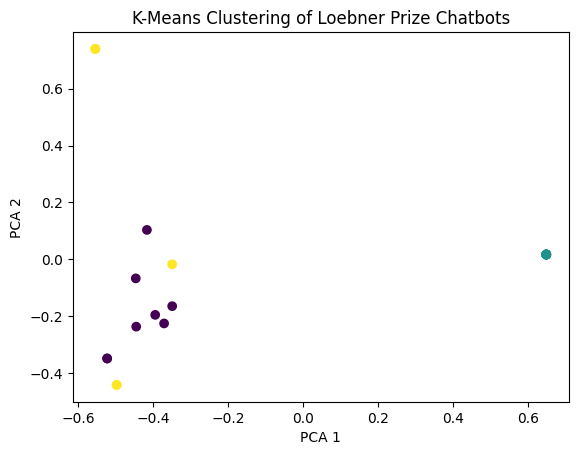

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(X.toarray())

plt.scatter(reduced[:, 0], reduced[:, 1], c=df['cluster'])
plt.title("K-Means Clustering of Loebner Prize Chatbots")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [7]:
for col in ['Chatbot', 'Description']:
    print(col, col in df.columns)

Chatbot False
Description True
